# Power Demand Prediction
First, importing all the necessary libraries. <br>I'm sticking to the basics here: `pandas` and `numpy` for the heavy lifting with data cleaning,<br>`matplotlib` for the final visualizations, and<br>`RandomForestRegressor` for the final predictions. I'll break down the exact logic behind why I chose this specific model over others later on the summary report.



In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

### 1. Ingesting and Securing the Grid Data
Now bringing in the main dataset. Instead of manually converting the file to a CSV beforehand, I'm using `pd.read_excel` to ingest the raw `.xlsx` file directly. It takes a few seconds longer to run, but it keeps the pipeline fully automated and reproducible.<br>

Because we are dealing with time-series data, keeping the timeline strictly chronological is critical.<br>I'm formatting the datetime column and immediately sorting it. If the rows get shuffled, we risk the scenario of accidentally leaking future data into past training sets.<br>

By running a quick `.info()` I am showing that we have successfully converted the datetime column's object as datetime object. ALso here it shows we're starting with 92,650 rows and 15 columns. But as we'll see in the next block, most of these columns are supply-side metrics that we actually need to drop.

In [2]:
df1 = pd.read_excel('Dataset/PGCB_date_power_demand.xlsx')
# Ensure the datetime column is actually treated as a datetime object
df1['datetime'] = pd.to_datetime(df1['datetime'])

# Sorting chronologically to prevent any data leakage issues
df1 = df1.sort_values('datetime')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92650 entries, 24 to 92637
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal               

### 2. Standardizing the Timeline (60/40 Split)
The raw data has some weird overlapping timestamps (like double readings at 10:00 and 10:30). Instead of just taking a basic average, I wrote a custom function to apply a 60/40 weighted split, prioritizing the top-of-the-hour reading. After that, I reindex the whole dataset into a strict 1-hour grid. This forces any "missing" hours to show up as empty rows so we can actually deal with them.

In [3]:
#Enforcing the Hourly Grid with a Weighted Average
df1_cleaned = df1.copy()
# Forcing minutes like :30 to round down to the nearest hour (:00)
df1_cleaned['datetime'] = df1_cleaned['datetime'].dt.floor('H')

# Custom Weighted Average Function for duplicate hours
def custom_weighted_avg(group):
    # If an hour has two entries (e.g., 10:00 and 10:30)
    if len(group) == 2:
        return (group.iloc[0] * 0.60) + (group.iloc[1] * 0.40) # 60/40 Split
    # If it's just a single entry, we are keeping it as is
    return group.mean()

# Applying the weighted average
df_hourly = df1_cleaned.groupby('datetime')['demand_mw'].apply(custom_weighted_avg).reset_index()

# Creating the perfect chronological timeline to expose missing hours
full_time_range = pd.date_range(start=df_hourly['datetime'].min(), 
                                end=df_hourly['datetime'].max(), freq='1H')
df_hourly = df_hourly.set_index('datetime').reindex(full_time_range).rename_axis('datetime').reset_index()

C:\Users\icehe\AppData\Local\Temp\ipykernel_13724\2199392622.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df1_cleaned['datetime'] = df1_cleaned['datetime'].dt.floor('H')
C:\Users\icehe\AppData\Local\Temp\ipykernel_13724\2199392622.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time_range = pd.date_range(start=df_hourly['datetime'].min(),


### 3. Backward-Looking Anomaly Detection & Threshold Testing
Power grids experience natural, massive spikes during extreme weather. If we are using`1.5 * IQR`, we risk deleting valid peak-demand events (heatwaves), which blinds the model to extreme scenarios.<br> 

To prove this, the pipeline calculates the data loss at `1.5`, `2.0`, and `2.5` IQR multipliers before applying the most conservative `2.5` threshold to ensure we only delete actual hardware sensor failures. The calculation uses a 7-day rolling window (`center=False`) to strictly prevent data leakage.<br>Any impossible limits or statistical anomalies get flagged as `NaN`.

In [4]:
# Converting to numeric, forcing hidden text errors to NaN
df_hourly['demand_mw'] = pd.to_numeric(df_hourly['demand_mw'], errors='coerce')

# Calculating the IQR boundary using ONLY the past 7 days (168 hours). 
Q1_rolling = df_hourly['demand_mw'].rolling(window=168, center=False, min_periods=1).quantile(0.25)
Q3_rolling = df_hourly['demand_mw'].rolling(window=168, center=False, min_periods=1).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

#THRESHOLD TESTING
#Here calculating how many rows would be flagged at different strictness levels
outliers_15 = ((df_hourly['demand_mw'] < Q1_rolling - 1.5 * IQR_rolling) | (df_hourly['demand_mw'] > Q3_rolling + 1.5 * IQR_rolling)).sum()
outliers_20 = ((df_hourly['demand_mw'] < Q1_rolling - 2.0 * IQR_rolling) | (df_hourly['demand_mw'] > Q3_rolling + 2.0 * IQR_rolling)).sum()

# Definining my chosen 2.5 bounds
lower_bound = Q1_rolling - 2.5 * IQR_rolling
upper_bound = Q3_rolling + 2.5 * IQR_rolling
outliers_25 = ((df_hourly['demand_mw'] < lower_bound) | (df_hourly['demand_mw'] > upper_bound)).sum()

print("ANOMALY DETECTION THRESHOLD TEST")
print(f"Rows flagged by 1.5 IQR: {outliers_15}")
print(f"Rows flagged by 2.0 IQR: {outliers_20}")
print(f"Rows flagged by 2.5 IQR: {outliers_25}")
print("Proceeding with 2.5 IQR to preserve natural peak-demand spikes.\n")

#APPLYING THE FILTER
# Flagging impossible physical limits (<2000 or >20000) and statistical anomalies as NaN
df_hourly.loc[(df_hourly['demand_mw'] < 2000) | 
              (df_hourly['demand_mw'] > 20000) | 
              (df_hourly['demand_mw'] < lower_bound) | 
              (df_hourly['demand_mw'] > upper_bound), 'demand_mw'] = np.nan

ANOMALY DETECTION THRESHOLD TEST
Rows flagged by 1.5 IQR: 933
Rows flagged by 2.0 IQR: 384
Rows flagged by 2.5 IQR: 214
Proceeding with 2.5 IQR to preserve natural peak-demand spikes.



### 4. Imputing Missing Values (Zero leakage)
Now we have gaps from the missing grid hours and the anomalies we just stripped out. I'm strictly using `.ffill()` (forward-fill) to plug these holes. We can't interpolate using tomorrow's data to guess today's missing value, so carrying the last known value forward is the most robust, leak-free approach.

In [5]:
#Filling Missing Values using STRICTLY PREVIOUS DATA
df_hourly['demand_mw'] = df_hourly['demand_mw'].ffill()

# Because ffill can't fill the very first row if it's missing, we are backfilling just the starting edge
df_hourly['demand_mw'] = df_hourly['demand_mw'].bfill()

print(f"Shape after strict cleaning: {df_hourly.shape}")
print(f"Missing Values left: {df_hourly['demand_mw'].isna().sum()}")
print("Data is clean, weighted, and 100% free of data leakage!")

# Renaming back to df1_cleaned so it works seamlessly with the rest of our pipeline
df1_cleaned = df_hourly.copy()

Shape after strict cleaning: (89101, 2)
Missing Values left: 0
Data is clean, weighted, and 100% free of data leakage!


### 5. Transforming Weather Data
Power demand doesn't happen in a vacuum—it is heavily driven by immediate meteorological conditions (like heatwaves causing a spike in AC usage). Here, I'm loading in the historical weather data and standardizing the `datetime` column so it perfectly matches our hourly grid timeline.

In [6]:
df_weather = pd.read_excel('Dataset/weather_data.xlsx', skiprows=3)

# Renaming and formatting times
df_weather = df_weather.rename(columns={'time': 'datetime'})
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])

print("Weather columns loaded successfully:", df_weather.columns.tolist())

Weather columns loaded successfully: ['datetime', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']


### 6A. Domain Driven Feature Selection(for 'economic_full_1.csv')
The raw World Bank dataset contains 1516 distinct economic indicators. Manually reviewing these would be inefficient, and feeding all of them into a model would cause massive overfitting and multicollinearity. 

Instead, I used Python to programmatically search for three specific "proxy" targets that govern physical grid expansion: **Population** (domestic base-load), **Industry** (heavy commercial load), and **GDP** (standard of living/appliance adoption).

In [7]:
df_eco = pd.read_csv('Dataset/economic_full_1.csv')
# Programmatically hunting for our domain targets
all_indicators = df_eco['Indicator Name'].dropna().unique()
search_results = [col for col in all_indicators if 'GDP' in str(col) or 'Population' in str(col) or 'Industry' in str(col)]
print(f"Programmatic search narrowed 1,500+ columns down to {len(search_results)} potential matches.")

# Showing a quick preview of the raw search results to prove the programmatic filter worked
print("Sample of raw search results found:")
print(search_results[:5])

print("Proceeding to extract the 3 cleanest baseline metrics from this whole 159 list\n")
for col in search_results:
    if col in ['GDP growth (annual %)', 'Population, total', 'Industry (including construction), value added (annual % growth)']:
        print(f"'{col}'")

Programmatic search narrowed 1,500+ columns down to 159 potential matches.
Sample of raw search results found:
['Population, male', 'Population ages 80 and above, female (% of female population)', 'Population ages 70-74, female (% of female population)', 'Population ages 65 and above, male', 'Population ages 65-69, female (% of female population)']
Proceeding to extract the 3 cleanest baseline metrics from this whole 159 list

'Industry (including construction), value added (annual % growth)'
'Population, total'
'GDP growth (annual %)'


### 6B.Macroeconomic Data Reshaping (Melt & Pivot)
AFter knowing the indicators we have to fix the shape of the data. The World Bank file is in a "wide" format (every year gets its own column), which our model can't process. <br>

For this, I used a two step transformation:<br>
1. `.melt()`: Squashes all 60+ individual year columns down into one single `Year` column.<br>
2. `.pivot_table()`: Pulls out our 3 chosen economic metrics and turns them into their own clean feature columns.<br>

Finally, I renamed the columns so they merge flawlessly with our hourly power grid dataset in the next step.

In [8]:
# Melt: Collapsing all the year columns into two columns: 'Year' and 'Value'
id_vars = ['Country Name', 'Indicator Name', 'Indicator Code']
df_eco_melted = df_eco.melt(id_vars=id_vars, var_name='Year', value_name='Value')

# Converting Year to numeric, and dropping the empty
df_eco_melted['Year'] = pd.to_numeric(df_eco_melted['Year'], errors='coerce')
df_eco_melted = df_eco_melted.dropna(subset=['Year'])

# Pivot: Turnning our indicators into columns
df_eco_pivoted = df_eco_melted.pivot_table(index='Year', columns='Indicator Name', values='Value').reset_index()

# Selecting our 3 core macroeconomic drivers
selected_indicators = [
    'GDP growth (annual %)', 
    'Population, total',
    'Industry (including construction), value added (annual % growth)'
]
eco_cols = ['Year'] + selected_indicators
df_eco_final = df_eco_pivoted[eco_cols].copy()

# Renaming columns to be cleaner for the model
df_eco_final.columns = ['Year', 'gdp_growth', 'population_total', 'industry_growth']

### 7.Assembling the Pipeline(merging all)

I am specifically using a `left` merge here instead of the default `inner` merge. This is a critical safety measure. Our main priority is the power grid data; if the weather or economic datasets happen to be missing a random hour or year, an `inner` merge would accidentally delete that row of our precious target data. A `left` merge guarantees our hourly power timeline stays 100% intact.

1. **Weather Merge:** joined exactly on the hourly `datetime`.
2. **Economic Merge:** since the macro-stats are annual, I created a temporary `Year` column from our timeline to act as a bridge, merged the data, and then dropped the bridge to keep the final dataframe clean.

In [9]:
# Creating a 'Year' column in our main dataset to join the economic data
df1_cleaned['Year'] = df1_cleaned['datetime'].dt.year

# First Merge: Weather Data (on exact datetime)
# We use 'left' merge to ensure we don't lose any of our target hourly grid
df_master = pd.merge(df1_cleaned, df_weather, on='datetime', how='left')

# Second Merge: Economic Data (on Year)
df_master = pd.merge(df_master, df_eco_final, on='Year', how='left')

# Dropping the helper 'Year' column
df_master = df_master.drop(columns=['Year'])

print("Master dataset shape after merges:", df_master.shape)
print("Missing values in weather features:", df_master['temperature_2m (°C)'].isna().sum())

Master dataset shape after merges: (89101, 14)
Missing values in weather features: 0


### 8. Temporal Feature Engineering (Supervised Setup)
A Random Forest does not inherently understand the concept of "time" or sequence like an LSTM or ARIMA model would. We have to manually translate the flow of time into mathematical columns.

This block transforms our historical dataset into a Supervised Machine Learning problem:
1. **The Target (`shift(-1)`):** We shift the grid demand backward by one hour. This aligns "current weather and time" with "next hour's demand" on the exact same row, allowing the model to learn how to predict the future.
2. **Human Behavior (Time Flags):** Extracting the hour, month, and weekend flags teaching the model about human seasonality (e.g., offices close on weekends; AC spikes in summer months).
3. **Grid Memory (Lags):** We give the model auto-regressive "memory" by showing it what happened 1 hour ago, 24 hours ago, and 1 week (168 hours) ago.
4. **Grid Momentum (Rolling):** Moving averages help the model understand if the grid load is currently ramping up or stabilizing.
5. sGenerating these lags and leads mathematically creates `NaN` values at the very beginning and very end of the dataset, which we safely drop before training.*

In [10]:
# Ensuring data is strictly sorted chronologically just to be safe
df_master = df_master.sort_values('datetime').reset_index(drop=True)

#A. Creating the target variable (y) for supervised learning
# We want to predict the next hour's demand, so we shift the column backwards by 1
df_master['target_next_hour_demand'] = df_master['demand_mw'].shift(-1)

#B. Datetime Flags
df_master['hour'] = df_master['datetime'].dt.hour
df_master['day_of_week'] = df_master['datetime'].dt.dayofweek 
df_master['month'] = df_master['datetime'].dt.month
# We will use standard 5 and 6 (Sat/Sun) for the mathematical flag.(0=Monday, 6=Sunday)
df_master['is_weekend'] = df_master['day_of_week'].isin([5, 6]).astype(int)

#C. Lag Features
# Current row represents time 't'
# demand_mw is the demand at time 't'
df_master['lag_1h'] = df_master['demand_mw'].shift(1)     # Demand at t-1
df_master['lag_24h'] = df_master['demand_mw'].shift(24)   # Demand at t-24 (Yesterday)
df_master['lag_168h'] = df_master['demand_mw'].shift(168) # Demand at t-168 (Last Week)

#D. Rolling Aggregates
# We calculate moving averages up to the current hour 't'
df_master['rolling_mean_3h'] = df_master['demand_mw'].rolling(window=3).mean()
df_master['rolling_mean_24h'] = df_master['demand_mw'].rolling(window=24).mean()
df_master['rolling_std_24h'] = df_master['demand_mw'].rolling(window=24).std() # Capturing volatility

#E. Cleaning up NaN values(created by Shifting and Rolling at the edges of the dataset)
print(f"Shape before dropping NaNs: {df_master.shape}")
df_final = df_master.dropna().copy()
print(f"Shape after dropping NaNs: {df_final.shape}")

#F. sample of our supervised learning table
print("\nPreview of Supervised Setup")
df_final.head()

Shape before dropping NaNs: (89101, 25)
Shape after dropping NaNs: (84912, 25)

Preview of Supervised Setup


,datetime,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),...,hour,day_of_week,month,is_weekend,lag_1h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h
168,2015-04-26 00:00:00,6167.0,22.0,91,24.6,0.0,20.5,24.1,71,92,...,0,6,4,1,6167.0,5197.0,4821.0,6167.0,4830.391667,898.697524
169,2015-04-26 01:00:00,6167.0,21.8,93,24.7,0.0,20.6,23.9,72,97,...,1,6,4,1,6167.0,4987.0,3612.0,6167.0,4879.558333,939.011865
170,2015-04-26 02:00:00,6167.0,21.6,94,24.7,0.0,20.6,23.8,60,99,...,2,6,4,1,6167.0,4703.0,3727.0,6167.0,4940.558333,973.945912
171,2015-04-26 03:00:00,6167.0,21.4,94,24.7,0.0,20.5,23.6,47,84,...,3,6,4,1,6167.0,4510.0,3632.0,6167.0,5009.600000,1000.467312
172,2015-04-26 04:00:00,6167.0,21.5,94,24.6,0.0,20.5,23.5,43,92,...,4,6,4,1,6167.0,4230.0,3641.0,6167.0,5090.308333,1012.894430


### 9. Pipeline Finalization & Filtering
Before passing the data to the Random Forest, we need to enforce strict feature selection and handle any remaining missing values.

1. **Explicit Column Filtering:** I explicitly defined a list of permitted columns. This guarantees that no noisy, rogue columns accidentally leak into the model.
2. **Zero-Leakage Policy:** as per the strict project constraints regarding missing data, we cannot look into the future to fill missing values. Therefore, I am actively choosing not to backfill (`bfill`) any missing early macroeconomic data. Instead, I am using a strict `.dropna()` to remove the first 168 rows (due to our 1-week lag features) and any early timestamps lacking historical context.

In [11]:
#Explicitly listing only the columns we actually want our model to use
features_to_keep = [
    'datetime', 'demand_mw', 'target_next_hour_demand', # Core
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'cloud_cover (%)', # Weather
    'gdp_growth', 'population_total', 'industry_growth', # Economics
    'hour', 'day_of_week', 'month', 'is_weekend', # Datetime Flags
    'lag_1h', 'lag_24h', 'lag_168h', # Lags
    'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h' # Rolling Trends
]

# Keep only valid features (this safely ignores the messy solar/wind columns)
valid_features = [col for col in features_to_keep if col in df_master.columns]
df_filtered = df_master[valid_features].copy()

#zero leakage dropping 
df_final = df_filtered.dropna().copy()

print(f"Dataset strictly filtered. Total clean rows ready for model: {df_final.shape[0]}")

Dataset strictly filtered. Total clean rows ready for model: 84912


### 10. Model Training & Evaluation (Random Forest Baseline)
With the dataset strictly filtered and engineered, we move to the modeling phase. 

1. **Chronological Boundary:** As Per the strict project requirements, the timeline is hard-split at `2023-12-31`.
2. **Algorithm Choice (Random Forest):** I selected a Random Forest Regressor as the forecasting engine. Power demand has highly non-linear relationships with time and weather (e.g., demand spikes non-linearly when temperature crosses a certain AC-trigger threshold). Tree-based models capture these non-linearities natively without requiring complex feature scaling.
3. **Hyperparameter Tuning (`max_depth=20`):** Time-series data is notoriously easy to overfit. If left unconstrained, the Random Forest would grow infinitely deep and just memorize the 2015-2023 data. By restricting `max_depth` to 20(explanation providedss in the summary report), I force the trees to learn generalized, robust patterns that will survive the transition into the unseen 2024 test data.
4. **Evaluation:** The final performance is evaluated using **MAPE** (Mean Absolute Percentage Error), as per the requirement of this task.

In [12]:
# A. Strict Chronological Split
# We will train on data up to the end of 2023, and test on 2024 onwards
train_df = df_final[df_final['datetime'].dt.year < 2024]
test_df = df_final[df_final['datetime'].dt.year >= 2024]

# Defining Features (X) and Target (y)
# We drop 'datetime' because classical models only accept numbers.
# We obviously drop the target variable from our features!
features_to_drop = ['datetime', 'target_next_hour_demand']

X_train = train_df.drop(columns=features_to_drop)
y_train = train_df['target_next_hour_demand']

X_test = test_df.drop(columns=features_to_drop)
y_test = test_df['target_next_hour_demand']

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

# B. Initializing and Training the Model
print("\nTraining Random Forest Baseline...")
# n_jobs=-1 uses all our computer's cores to speed up training
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# C. Making Predictions and Evaluating
predictions = rf_model.predict(X_test)

#Calculating MAPE as a percentage
mape_score = mean_absolute_percentage_error(y_test, predictions)
print(f"\nFinal Test MAPE Score: {mape_score * 100:.2f}%")

Training rows: 76128
Testing rows: 8784

Training Random Forest Baseline...

Final Test MAPE Score: 1.94%


### 11.Feature Importance
We need to know why the model makes its predictions. This block extracts the Feature Importance from the Random Forest to see which variables carry the most weight.

Feature Importance Plot saved as 'feature_importance_plot.png'

Top 5 Most Important Features


demand_mw: 96.53% relative weight
hour: 1.64% relative weight
temperature_2m (°C): 0.36% relative weight
lag_1h: 0.29% relative weight
rolling_mean_24h: 0.28% relative weight


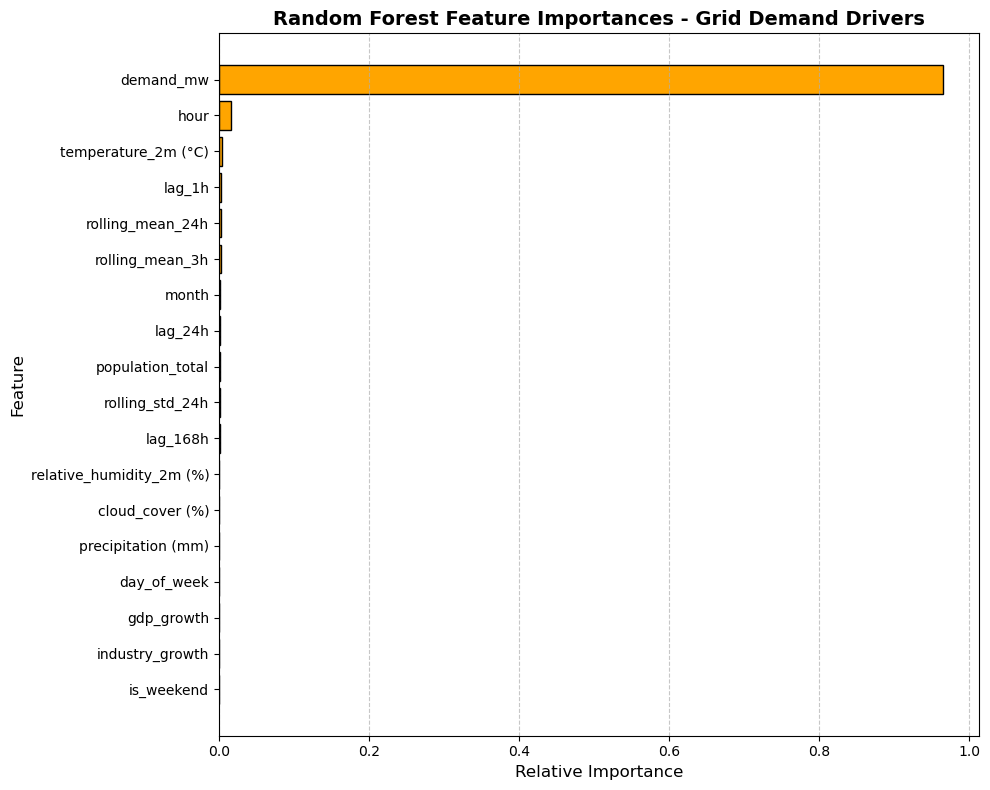

In [13]:
# Extracting feature importances from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Creating a DataFrame to hold the features and their importance scores
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sorting the DataFrame to show the most important features at the top
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='orange', edgecolor='black')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest Feature Importances - Grid Demand Drivers', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjusting layout so labels don't get cut off
plt.tight_layout()

# Saving the plot
plt.savefig('feature_importance_plot.png', dpi=300)
print("Feature Importance Plot saved as 'feature_importance_plot.png'")

# Printing the top 5 drivers textually
print("\nTop 5 Most Important Features")
print("\n")
top_5 = fi_df.sort_values(by='Importance', ascending=False).head(5)
for index, row in top_5.iterrows():
    print(f"{row['Feature']}: {row['Importance']*100:.2f}% relative weight")